<a href="https://colab.research.google.com/github/KavyaKShetty5/PriorAuthAutomation/blob/main/PR_Automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problem Statement**

### Business Context

The healthcare industry is increasingly adopting digital systems such as Electronic Medical Records (EMR) to streamline clinical and administrative workflows. Despite these advancements, the Prior Authorization (PA) process remains a significant bottleneck (Allen & Saba, 2023). PA requires healthcare providers to obtain approval from insurance payers before delivering certain treatments, procedures, or medications. While intended to control costs and ensure appropriate care, the process is largely manual and inefficient (Lenert et al., 2023)

Healthcare systems such as EPIC and Cerner integrate PA workflows; however, these systems still rely heavily on manual documentation, rule-based checks, and human intervention. This leads to delays in treatment, increased administrative workload, and potential negative patient outcomes (HCLTech, 2023).  According to industry reports, physicians spend several hours weekly on PA-related tasks, contributing to burnout and inefficiencies (McKinsey & Company, 2022)
Artificial Intelligence (AI), particularly machine learning and natural language processing, offers promising solutions to automate decision-making and reduce manual effort (Frontiers Editorial Team, 2025).


### Problem Definition

The current prior authorization process is inefficient, inconsistent, and resource-intensive (Allen & Saba, 2023). It involves manual data entry, fragmented communication between providers and payers, and reliance on incomplete or unstructured clinical documentation. These challenges result in delayed approvals, high denial rates, and increased operational costs (Lenert et al., 2023). There is a lack of intelligent systems capable of predicting authorization outcomes and assisting providers in preparing complete and accurate submissions. This gap leads to suboptimal decision-making and inefficiencies in healthcare delivery. Therefore, there is a need for an AI-driven solution to automate and optimize the prior authorization process (Aiwerioghene & Osuchukwu, 2025).

### Data Dictionary

* `Patient_ID`: Unique identifier for each patient.
* `Encounter_ID`: Unique identifier for each healthcare encounter.
* `Age`: Age of the patient.
* `Gender`: Gender of the patient.
* `Diagnosis_Code`: Medical diagnosis code.
* `Diagnosis_Description`: Description of the diagnosis.
* `Procedure_Code`: Medical procedure code.
* `Procedure_Description`: Description of the procedure.
* `Comorbidity_Count`: Number of co-existing medical conditions.
* `Procedure_Cost`: Cost of the procedure.
* `Insurance_Type`: Type of insurance the patient has.
* `Provider_Type`: Type of healthcare provider.
* `Claim_Amount_Paid`: Amount paid by the insurance claim.
* `Clinical_Notes`: Clinical notes related to the encounter.
* `Severity_Level`: Severity level of the patient's condition.
* `Urgency_Level`: Urgency level of the procedure/treatment.
* `Condition_Type`: Type of medical condition (e.g., Acute, Chronic).
* `PA_Status`: Prior Authorization status (Approved/Denied).
* `Submission_Type`: Type of submission (e.g., AI, Manual).
* `Turnaround_Time`: Time taken for prior authorization approval in days.
* `Encounter_Date`: Date of the healthcare encounter.

## **Installing and Importing Necessary Libraries**

In [1]:
import sys

# Install system-level FFmpeg and its development libraries
# These are dependencies for torchcodec (used by sentence_transformers)
!apt-get update -qq # Use -qq for quiet update
!apt-get install -y ffmpeg libavcodec-dev libavformat-dev libswscale-dev libavutil-dev # Install core ffmpeg and dev libs

# Install all required Python libraries, allowing pip to resolve dependencies more harmoniously
# Explicitly pinning torch to 2.10.0 to address reported torchcodec incompatibility
!pip install numpy pandas scipy scikit-learn tensorflow tensorflow-text seaborn gensim sentence_transformers torch==2.10.0 tqdm matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
The following NEW packages will be installed:
  libavcodec-dev libavformat-dev libavutil-dev libswresample-dev
  libswscale-dev
0 upgraded, 5 newly installed, 0 to remove and 8 not upgraded.
Need to get 8,279 kB of archives.
After this operation, 30.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libavutil-dev amd64 7:4.4.2-0ubuntu0.22.04.1 [427 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libswresample-dev amd64 7:4.4.2-0ubuntu0.22.04.1 [78.0 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libavcodec-dev amd64 7:4.4.2-0ubuntu0.

In [2]:
# To manipulate and analyze data
import pandas as pd
import numpy as np

# To visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# To used time-related functions
import time

# To parse JSON data
import json

# To build, tune, and evaluate ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# To load/create word embeddings
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

# To work with transformer models
import torch
from sentence_transformers import SentenceTransformer

# To implement progress bar related functionalities
from tqdm import tqdm
tqdm.pandas()

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

## **Loading the dataset**

Import necessary libraries

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Load data from google drive
preauthData = pd.read_csv("/content/drive/MyDrive/MS_Labs/Term3_Capstone/Data/prior_authorization_dataset_wa_cms.csv")


In [5]:
print("Shape of preauthData:", preauthData.shape)

Shape of preauthData: (9082, 21)


## Core Data Preprocessing

In [43]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np # For np.inf in Age_Group bins

# 1. Handle Duplicates and create 'pa'
pa = preauthData.drop_duplicates()
print(f"Number of records after dropping duplicates: {pa.shape[0]}")

# 2. Create 'approval' column from 'PA_Status'
pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})
print("Created 'approval' column.")

# 3. Ensure 'Clinical_Notes' is string type
pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)
print("Ensured 'Clinical_Notes' is string type.")

# 4. Make a copy to work with 'df' and process 'Date' column
df = pa.copy()
df['Date'] = pd.to_datetime(df['Encounter_Date'], format='%d-%m-%Y')
print("Created 'Date' column from 'Encounter_Date'.")

# 5. Drop original ID and status columns from df
df = df.drop(columns=['Encounter_ID', 'Encounter_Date', 'PA_Status'], errors='ignore')
print("Dropped original ID and status columns.")

# 6. Extract temporal features from 'Date'
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
print("Extracted temporal features (Year, Month, Day, DayOfWeek).")

# 7. Apply One-Hot Encoding for specific categorical features
categorical_cols_onehot = [
    'Gender', 'Insurance_Type', 'Provider_Type', 'Severity_Level',
    'Urgency_Level', 'Condition_Type', 'Submission_Type'
]
existing_categorical_cols = [col for col in categorical_cols_onehot if col in df.columns]
if existing_categorical_cols:
    df = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=True)
    print(f"One-hot encoded: {existing_categorical_cols}")

# 8. Apply Label Encoding for Diagnosis_Code and Procedure_Code
categorical_cols_labelencode = ['Diagnosis_Code', 'Procedure_Code']
for col in categorical_cols_labelencode:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        print(f"Label encoded '{col}'.")

# Display the first few rows of the fully preprocessed df
print("\nFirst 5 rows of the fully preprocessed DataFrame after core steps:")
display(df.head())

Number of records after dropping duplicates: 9082
Created 'approval' column.
Ensured 'Clinical_Notes' is string type.
Created 'Date' column from 'Encounter_Date'.
Dropped original ID and status columns.
Extracted temporal features (Year, Month, Day, DayOfWeek).
One-hot encoded: ['Gender', 'Insurance_Type', 'Provider_Type', 'Severity_Level', 'Urgency_Level', 'Condition_Type', 'Submission_Type']
Label encoded 'Diagnosis_Code'.
Label encoded 'Procedure_Code'.

First 5 rows of the fully preprocessed DataFrame after core steps:


,Patient_ID,Age,Diagnosis_Code,Diagnosis_Description,Procedure_Code,Procedure_Description,Comorbidity_Count,Procedure_Cost,Claim_Amount_Paid,Clinical_Notes,...,Gender_Male,Insurance_Type_Medicare,Insurance_Type_Private,Provider_Type_Hospital,Severity_Level_Low,Severity_Level_Medium,Urgency_Level_Routine,Urgency_Level_Urgent,Condition_Type_Chronic,Submission_Type_Manual
0,P1,67,0,Type 2 Diabetes,1267,Ext Amb Infusn Pump Insulin,1,3942,2060,"Chronic disease, requires continuous monitoring",...,True,False,False,True,False,True,False,True,False,True
1,P2,30,0,Type 2 Diabetes,1266,External Ambulatory Infus Pu,2,8252,4563,"Chronic disease, requires continuous monitoring",...,False,False,True,False,False,True,False,True,True,False
2,P3,63,0,Type 2 Diabetes,1175,Monitoring feature/deviceNOC,2,6044,3675,"Chronic disease, requires continuous monitoring",...,True,False,True,True,False,False,False,False,True,False
3,P4,33,0,Type 2 Diabetes,1267,Ext Amb Infusn Pump Insulin,4,9663,5804,Patient shows severe symptoms and requires imm...,...,False,False,False,True,False,False,False,True,False,False
4,P5,21,0,Type 2 Diabetes,1266,External Ambulatory Infus Pu,2,5531,4549,"Stable condition, periodic evaluation needed",...,False,False,True,False,False,False,False,True,True,True


## Core Data Preprocessing

In [42]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np # For np.inf in Age_Group bins

# 1. Handle Duplicates and create 'pa'
pa = preauthData.drop_duplicates()
print(f"Number of records after dropping duplicates: {pa.shape[0]}")

# 2. Create 'approval' column from 'PA_Status'
pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})
print("Created 'approval' column.")

# 3. Ensure 'Clinical_Notes' is string type
pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)
print("Ensured 'Clinical_Notes' is string type.")

# 4. Make a copy to work with 'df' and process 'Date' column
df = pa.copy()
df['Date'] = pd.to_datetime(df['Encounter_Date'], format='%d-%m-%Y')
print("Created 'Date' column from 'Encounter_Date'.")

# 5. Drop original ID and status columns from df
df = df.drop(columns=['Encounter_ID', 'Encounter_Date', 'PA_Status'], errors='ignore')
print("Dropped original ID and status columns.")

# 6. Extract temporal features from 'Date'
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
print("Extracted temporal features (Year, Month, Day, DayOfWeek).")

# 7. Apply One-Hot Encoding for specific categorical features
categorical_cols_onehot = [
    'Gender', 'Insurance_Type', 'Provider_Type', 'Severity_Level',
    'Urgency_Level', 'Condition_Type', 'Submission_Type'
]
existing_categorical_cols = [col for col in categorical_cols_onehot if col in df.columns]
if existing_categorical_cols:
    df = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=True)
    print(f"One-hot encoded: {existing_categorical_cols}")

# 8. Apply Label Encoding for Diagnosis_Code and Procedure_Code
categorical_cols_labelencode = ['Diagnosis_Code', 'Procedure_Code']
for col in categorical_cols_labelencode:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        print(f"Label encoded '{col}'.")

# Display the first few rows of the fully preprocessed df
print("\nFirst 5 rows of the fully preprocessed DataFrame after core steps:")
display(df.head())

Number of records after dropping duplicates: 9082
Created 'approval' column.
Ensured 'Clinical_Notes' is string type.
Created 'Date' column from 'Encounter_Date'.
Dropped original ID and status columns.
Extracted temporal features (Year, Month, Day, DayOfWeek).
One-hot encoded: ['Gender', 'Insurance_Type', 'Provider_Type', 'Severity_Level', 'Urgency_Level', 'Condition_Type', 'Submission_Type']
Label encoded 'Diagnosis_Code'.
Label encoded 'Procedure_Code'.

First 5 rows of the fully preprocessed DataFrame after core steps:


,Patient_ID,Age,Diagnosis_Code,Diagnosis_Description,Procedure_Code,Procedure_Description,Comorbidity_Count,Procedure_Cost,Claim_Amount_Paid,Clinical_Notes,...,Gender_Male,Insurance_Type_Medicare,Insurance_Type_Private,Provider_Type_Hospital,Severity_Level_Low,Severity_Level_Medium,Urgency_Level_Routine,Urgency_Level_Urgent,Condition_Type_Chronic,Submission_Type_Manual
0,P1,67,0,Type 2 Diabetes,1267,Ext Amb Infusn Pump Insulin,1,3942,2060,"Chronic disease, requires continuous monitoring",...,True,False,False,True,False,True,False,True,False,True
1,P2,30,0,Type 2 Diabetes,1266,External Ambulatory Infus Pu,2,8252,4563,"Chronic disease, requires continuous monitoring",...,False,False,True,False,False,True,False,True,True,False
2,P3,63,0,Type 2 Diabetes,1175,Monitoring feature/deviceNOC,2,6044,3675,"Chronic disease, requires continuous monitoring",...,True,False,True,True,False,False,False,False,True,False
3,P4,33,0,Type 2 Diabetes,1267,Ext Amb Infusn Pump Insulin,4,9663,5804,Patient shows severe symptoms and requires imm...,...,False,False,False,True,False,False,False,True,False,False
4,P5,21,0,Type 2 Diabetes,1266,External Ambulatory Infus Pu,2,5531,4549,"Stable condition, periodic evaluation needed",...,False,False,True,False,False,False,False,True,True,True


## **Data Overview**

## Core Data Preprocessing (Re-added to ensure `df` is correctly initialized)

In [41]:
# 1. Handle Duplicates and create 'pa' (mimicking previous steps)
pa = preauthData.drop_duplicates()
print(f"Number of records after dropping duplicates: {pa.shape[0]}")

# 2. Create 'approval' column from 'PA_Status'
pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})
print("Created 'approval' column.")

# 3. Ensure 'Clinical_Notes' is string type
pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)
print("Ensured 'Clinical_Notes' is string type.")

# 4. Make a copy to work with 'df' and process 'Date' column
df = pa.copy()
df['Date'] = pd.to_datetime(df['Encounter_Date'], format='%d-%m-%Y')
print("Created 'Date' column from 'Encounter_Date'.")

# 5. Drop original ID and status columns from df
df = df.drop(columns=['Encounter_ID', 'Encounter_Date', 'PA_Status'], errors='ignore')
print("Dropped original ID and status columns.")

# 6. Extract temporal features from 'Date'
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
print("Extracted temporal features (Year, Month, Day, DayOfWeek).")

# 7. Apply One-Hot Encoding for specific categorical features
categorical_cols_onehot = [
    'Gender', 'Insurance_Type', 'Provider_Type', 'Severity_Level',
    'Urgency_Level', 'Condition_Type', 'Submission_Type'
]
existing_categorical_cols = [col for col in categorical_cols_onehot if col in df.columns]
if existing_categorical_cols:
    df = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=True)
    print(f"One-hot encoded: {existing_categorical_cols}")

# 8. Apply Label Encoding for Diagnosis_Code and Procedure_Code
from sklearn.preprocessing import LabelEncoder
categorical_cols_labelencode = ['Diagnosis_Code', 'Procedure_Code']
for col in categorical_cols_labelencode:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        print(f"Label encoded '{col}'.")

# Display the first few rows of the fully preprocessed df
print("\nFirst 5 rows of the fully preprocessed DataFrame:")
display(df.head())

Number of records after dropping duplicates: 9082
Created 'approval' column.
Ensured 'Clinical_Notes' is string type.
Created 'Date' column from 'Encounter_Date'.
Dropped original ID and status columns.
Extracted temporal features (Year, Month, Day, DayOfWeek).
One-hot encoded: ['Gender', 'Insurance_Type', 'Provider_Type', 'Severity_Level', 'Urgency_Level', 'Condition_Type', 'Submission_Type']
Label encoded 'Diagnosis_Code'.
Label encoded 'Procedure_Code'.

First 5 rows of the fully preprocessed DataFrame:


,Patient_ID,Age,Diagnosis_Code,Diagnosis_Description,Procedure_Code,Procedure_Description,Comorbidity_Count,Procedure_Cost,Claim_Amount_Paid,Clinical_Notes,...,Gender_Male,Insurance_Type_Medicare,Insurance_Type_Private,Provider_Type_Hospital,Severity_Level_Low,Severity_Level_Medium,Urgency_Level_Routine,Urgency_Level_Urgent,Condition_Type_Chronic,Submission_Type_Manual
0,P1,67,0,Type 2 Diabetes,1267,Ext Amb Infusn Pump Insulin,1,3942,2060,"Chronic disease, requires continuous monitoring",...,True,False,False,True,False,True,False,True,False,True
1,P2,30,0,Type 2 Diabetes,1266,External Ambulatory Infus Pu,2,8252,4563,"Chronic disease, requires continuous monitoring",...,False,False,True,False,False,True,False,True,True,False
2,P3,63,0,Type 2 Diabetes,1175,Monitoring feature/deviceNOC,2,6044,3675,"Chronic disease, requires continuous monitoring",...,True,False,True,True,False,False,False,False,True,False
3,P4,33,0,Type 2 Diabetes,1267,Ext Amb Infusn Pump Insulin,4,9663,5804,Patient shows severe symptoms and requires imm...,...,False,False,False,True,False,False,False,True,False,False
4,P5,21,0,Type 2 Diabetes,1266,External Ambulatory Infus Pu,2,5531,4549,"Stable condition, periodic evaluation needed",...,False,False,True,False,False,False,False,True,True,True


## Additional Data Cleaning and Feature Engineering

In [27]:
# Handle missing 'Procedure_Description' by filling with 'Unknown'
if 'Procedure_Description' in df.columns:
    df['Procedure_Description'] = df['Procedure_Description'].fillna('Unknown')
    print("Filled missing 'Procedure_Description' with 'Unknown'.")

# Ensure 'Diagnosis_Description' is string type and handle potential NaNs
if 'Diagnosis_Description' in df.columns:
    df['Diagnosis_Description'] = df['Diagnosis_Description'].astype(str).fillna('Unknown')
    print("Ensured 'Diagnosis_Description' is string type and handled potential NaNs.")

print(df[['Procedure_Description', 'Diagnosis_Description']].isnull().sum())

Filled missing 'Procedure_Description' with 'Unknown'.
Ensured 'Diagnosis_Description' is string type and handled potential NaNs.
Procedure_Description    0
Diagnosis_Description    0
dtype: int64


In [28]:
# Create 'Cost_Ratio' feature: Claim_Amount_Paid / Procedure_Cost
# Handle cases where Procedure_Cost might be zero to avoid division by zero errors
df['Cost_Ratio'] = df.apply(lambda row: row['Claim_Amount_Paid'] / row['Procedure_Cost'] if row['Procedure_Cost'] != 0 else 0, axis=1)
print("Created 'Cost_Ratio' feature.")

# Display descriptive statistics for the new feature
print(df['Cost_Ratio'].describe())

Created 'Cost_Ratio' feature.
count    9082.000000
mean        0.674570
std         0.157638
min         0.400062
25%         0.538980
50%         0.675024
75%         0.810575
max         0.949940
Name: Cost_Ratio, dtype: float64


In [29]:
# Create 'Age_Group' feature
bins = [0, 18, 45, 65, np.inf]
labels = ['Child', 'Adult', 'Middle_Aged', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
print("Created 'Age_Group' feature.")

# One-hot encode 'Age_Group'
df = pd.get_dummies(df, columns=['Age_Group'], drop_first=True)
print("One-hot encoded 'Age_Group'.")

# Display the first few rows with the new features
display(df.head())

Created 'Age_Group' feature.
One-hot encoded 'Age_Group'.


,Patient_ID,Age,Diagnosis_Code,Diagnosis_Description,Procedure_Code,Procedure_Description,Comorbidity_Count,Procedure_Cost,Claim_Amount_Paid,Clinical_Notes,...,Severity_Level_Low,Severity_Level_Medium,Urgency_Level_Routine,Urgency_Level_Urgent,Condition_Type_Chronic,Submission_Type_Manual,Cost_Ratio,Age_Group_Adult,Age_Group_Middle_Aged,Age_Group_Senior
0,P1,67,0,Type 2 Diabetes,1267,Ext Amb Infusn Pump Insulin,1,3942,2060,"Chronic disease, requires continuous monitoring",...,False,True,False,True,False,True,0.522577,False,False,True
1,P2,30,0,Type 2 Diabetes,1266,External Ambulatory Infus Pu,2,8252,4563,"Chronic disease, requires continuous monitoring",...,False,True,False,True,True,False,0.552957,True,False,False
2,P3,63,0,Type 2 Diabetes,1175,Monitoring feature/deviceNOC,2,6044,3675,"Chronic disease, requires continuous monitoring",...,False,False,False,False,True,False,0.608041,False,True,False
3,P4,33,0,Type 2 Diabetes,1267,Ext Amb Infusn Pump Insulin,4,9663,5804,Patient shows severe symptoms and requires imm...,...,False,False,False,True,False,False,0.600642,True,False,False
4,P5,21,0,Type 2 Diabetes,1266,External Ambulatory Infus Pu,2,5531,4549,"Stable condition, periodic evaluation needed",...,False,False,False,True,True,True,0.822455,True,False,False


### Prepare Features (X) and Target (y) and Perform Time-based Split

In [35]:
# Ensure 'approval' column exists and is numeric (0 or 1)
if 'PA_Status' in df.columns and 'approval' not in df.columns:
    df['approval'] = df['PA_Status'].map({'Approved':1, 'Denied':0})

# Define features (X) and target (y) before splitting
# Exclude Patient_ID, Clinical_Notes, PA_Status and Date-related original columns
initial_features_to_exclude = [
    'Patient_ID', 'Clinical_Notes', 'PA_Status', 'Date',
    'Encounter_ID', 'Encounter_Date', 'Diagnosis_Description', 'Procedure_Description'
]
X = df.drop(columns=[col for col in initial_features_to_exclude if col in df.columns], errors='ignore')
y = df['approval']

print(f"Shape of initial features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of initial features (X): (9082, 27)
Shape of target (y): (9082,)


In [36]:
# Create boolean masks for the splits based on the 'Date' column in df
# Assuming 'Date' column exists from earlier preprocessing
if 'Date' in df.columns:
    train_mask = (df['Date'] < '2024-01-01')
    val_mask = (df['Date'] >= '2024-01-01') & (df['Date'] < '2024-07-01')
    test_mask = (df['Date'] >= '2024-07-01')

    # Apply these masks to X and y
    X_train = X[train_mask].reset_index(drop=True)
    X_val = X[val_mask].reset_index(drop=True)
    X_test = X[test_mask].reset_index(drop=True)

    y_train = y[train_mask].reset_index(drop=True)
    y_val = y[val_mask].reset_index(drop=True)
    y_test = y[test_mask].reset_index(drop=True)

    print("Data split into training, validation, and test sets based on 'Date'.")
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
else:
    print("Error: 'Date' column not found in DataFrame. Cannot perform time-based split.")

Data split into training, validation, and test sets based on 'Date'.
X_train shape: (4512, 27), y_train shape: (4512,)
X_val shape: (2275, 27), y_val shape: (2275,)
X_test shape: (2295, 27), y_test shape: (2295,)


## Update Feature and Target Splits with New Features

Now that new features have been engineered, we need to redefine our feature set (X) and re-apply the train/validation/test masks to ensure all models use the latest processed data.

In [44]:
# Define features (X_base) from the fully processed df.
# Exclude Patient_ID, Clinical_Notes, the target 'approval', and the original 'Date' column itself,
# as well as the 'Diagnosis_Description' and 'Procedure_Description' (which are handled by encoding/filling).

features_to_exclude = [
    'Patient_ID', 'Clinical_Notes', 'approval', 'Date',
    'Diagnosis_Description', 'Procedure_Description'
]

X_base = df.drop(columns=[col for col in features_to_exclude if col in df.columns], errors='ignore')

# The target 'y' was already set in cell `e067c08e`.
# Re-create boolean masks for the splits based on the 'Date' column in df
# This ensures the masks are consistent with the current state of df
if 'Date' in df.columns:
    train_mask = (df['Date'] < '2024-01-01')
    val_mask = (df['Date'] >= '2024-01-01') & (df['Date'] < '2024-07-01')
    test_mask = (df['Date'] >= '2024-07-01')

    # Apply these newly created masks to X_base and the globally available 'y' to create the split dataframes
    X_train_base = X_base[train_mask].reset_index(drop=True)
    X_val_base = X_base[val_mask].reset_index(drop=True)
    X_test_base = X_base[test_mask].reset_index(drop=True)

    # The target splits y_train, y_val, y_test were already created in cell `c4813005`.
    # We will re-create them here to be consistent with the re-created masks and X_base for robustness.
    y_train = y[train_mask].reset_index(drop=True)
    y_val = y[val_mask].reset_index(drop=True)
    y_test = y[test_mask].reset_index(drop=True)

    print("\nData split into training, validation, and test sets based on 'Date'.")
    print(f"Shape of X_train_base: {X_train_base.shape}, y_train shape: {y_train.shape}")
    print(f"Shape of X_val_base: {X_val_base.shape}, y_val shape: {y_val.shape}")
    print(f"Shape of X_test_base: {X_test_base.shape}, y_test shape: {y_test.shape}")
else:
    print("Error: 'Date' column not found in DataFrame. Cannot perform time-based split.")


Data split into training, validation, and test sets based on 'Date'.
Shape of X_train_base: (4512, 21), y_train shape: (4512,)
Shape of X_val_base: (2275, 21), y_val shape: (2275,)
Shape of X_test_base: (2295, 21), y_test shape: (2295,)


## Model Training and Evaluation

We will now train and evaluate several classification models on our prepared dataset. For each model, we will assess its performance using Accuracy, F1-score, Recall, Precision, and the ROC-AUC score, along with a confusion matrix.

### 1. Logistic Regression

--- Logistic Regression Model Evaluation ---
Accuracy: 0.7486
F1-Score: 0.8562
Recall: 1.0000
Precision: 0.7486
ROC-AUC Score: 0.5632


<Figure size 600x400 with 0 Axes>

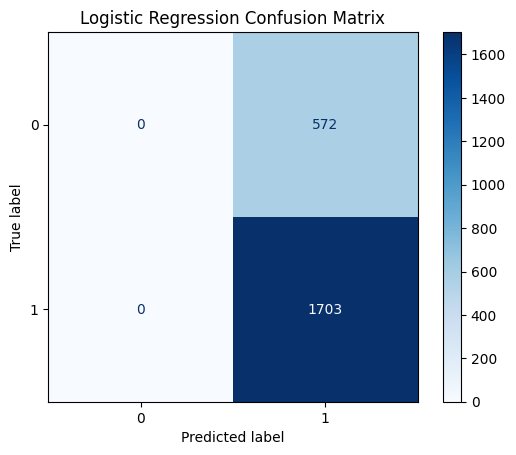

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg_model.fit(X_train_base, y_train)

# Predict on the validation set
y_pred_lr = log_reg_model.predict(X_val_base)
y_proba_lr = log_reg_model.predict_proba(X_val_base)[:, 1]

# Evaluate the model
print("--- Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_val, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_lr):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_proba_lr):.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(log_reg_model, X_val_base, y_val, cmap=plt.cm.Blues)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

### 2. Decision Tree

--- Decision Tree Model Evaluation ---
Accuracy: 0.6664
F1-Score: 0.7764
Recall: 0.7739
Precision: 0.7790
ROC-AUC Score: 0.5600


<Figure size 600x400 with 0 Axes>

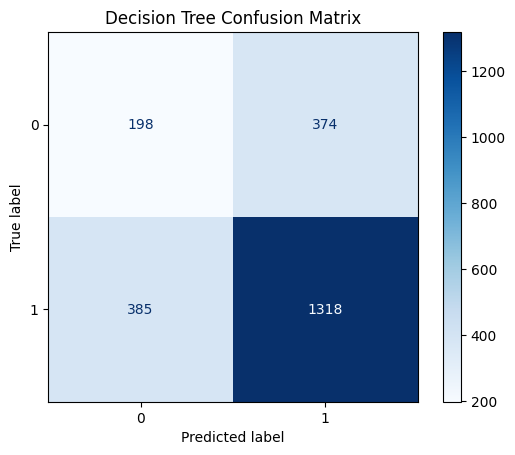

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_base, y_train)

# Predict on the validation set
y_pred_dt = dt_model.predict(X_val_base)
y_proba_dt = dt_model.predict_proba(X_val_base)[:, 1]

# Evaluate the model
print("--- Decision Tree Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_val, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_dt):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_proba_dt):.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(dt_model, X_val_base, y_val, cmap=plt.cm.Blues)
plt.title('Decision Tree Confusion Matrix')
plt.show()

### 3. Random Forest (Baseline)

--- Random Forest (Baseline) Model Evaluation ---
Accuracy: 0.7503
F1-Score: 0.8560
Recall: 0.9912
Precision: 0.7532
ROC-AUC Score: 0.6251


<Figure size 600x400 with 0 Axes>

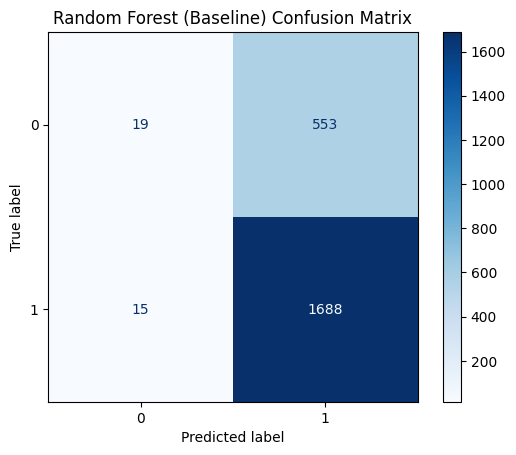

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Initialize and train the Random Forest model
rf_model_base = RandomForestClassifier(random_state=42)
rf_model_base.fit(X_train_base, y_train)

# Predict on the validation set
y_pred_rf_base = rf_model_base.predict(X_val_base)
y_proba_rf_base = rf_model_base.predict_proba(X_val_base)[:, 1]

# Evaluate the model
print("--- Random Forest (Baseline) Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf_base):.4f}")
print(f"F1-Score: {f1_score(y_val, y_pred_rf_base):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_rf_base):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_rf_base):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_proba_rf_base):.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(rf_model_base, X_val_base, y_val, cmap=plt.cm.Blues)
plt.title('Random Forest (Baseline) Confusion Matrix')
plt.show()

### 5. Hyperparameter Tuning for Random Forest (Baseline) using GridSearchCV

We will now use `GridSearchCV` to find the optimal hyperparameters for our Random Forest model. This involves defining a parameter grid and searching for the best combination that maximizes performance on the validation set.


Starting GridSearchCV for Random Forest...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
GridSearchCV finished.

Best parameters found: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best ROC-AUC score on training data with cross-validation: 0.6342

--- Tuned Random Forest Model Evaluation (on Validation Set) ---
Accuracy: 0.7512
F1-Score: 0.8573
Recall: 0.9982
Precision: 0.7512
ROC-AUC Score: 0.6444


<Figure size 600x400 with 0 Axes>

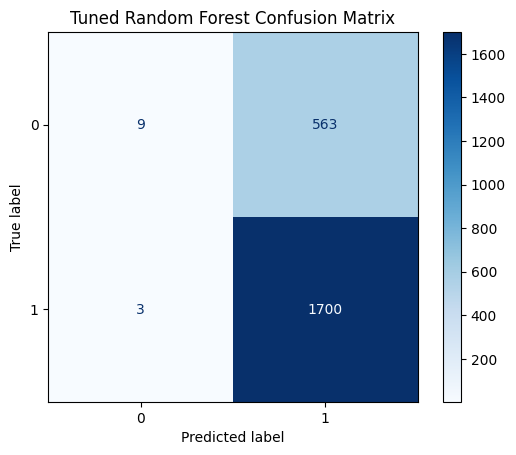

In [53]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [None, 10, 20], # Maximum depth of the tree
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required at each leaf node
    'min_samples_split': [2, 5, 10] # Minimum number of samples required to split an internal node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3, # 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=2, # Verbose output
    scoring='roc_auc' # Optimize for ROC-AUC score
)

# Fit GridSearchCV to the training data
print("\nStarting GridSearchCV for Random Forest...")
grid_search.fit(X_train_base, y_train)
print("GridSearchCV finished.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_rf_model = grid_search.best_estimator_

print(f"\nBest parameters found: {best_params}")
print(f"Best ROC-AUC score on training data with cross-validation: {best_score:.4f}")

# Evaluate the best model on the validation set
y_pred_rf_tuned = best_rf_model.predict(X_val_base)
y_proba_rf_tuned = best_rf_model.predict_proba(X_val_base)[:, 1]

print("\n--- Tuned Random Forest Model Evaluation (on Validation Set) ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf_tuned):.4f}")
print(f"F1-Score: {f1_score(y_val, y_pred_rf_tuned):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_rf_tuned):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_rf_tuned):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_proba_rf_tuned):.4f}")

# Plot Confusion Matrix for the tuned model
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(best_rf_model, X_val_base, y_val, cmap=plt.cm.Blues)
plt.title('Tuned Random Forest Confusion Matrix')
plt.show()

### 4. Random Forest with SMOTE for Imbalanced Data

First, let's check the class distribution of our target variable `y_train` to determine if SMOTE is necessary.

Original class distribution: Counter({1: 3438, 0: 1074})
Resampled class distribution: Counter({0: 3438, 1: 3438})

--- Random Forest (with SMOTE) Model Evaluation ---
Accuracy: 0.6905
F1-Score: 0.8044
Recall: 0.8503
Precision: 0.7633
ROC-AUC Score: 0.5962


<Figure size 600x400 with 0 Axes>

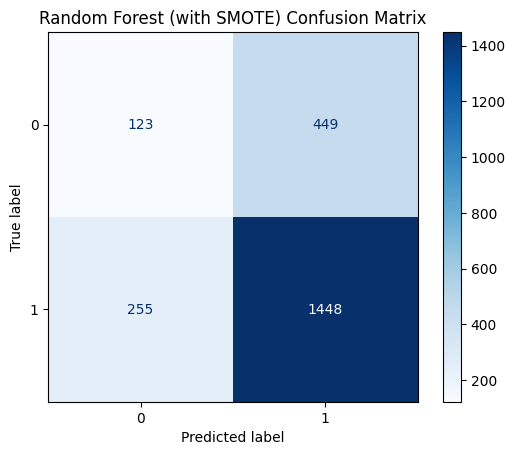

In [48]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Original class distribution:", Counter(y_train))

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_base, y_train)

print("Resampled class distribution:", Counter(y_train_smote))

# Initialize and train the Random Forest model with SMOTE-resampled data
rf_model_smote = RandomForestClassifier(random_state=42)
rf_model_smote.fit(X_train_smote, y_train_smote)

# Predict on the original validation set (do NOT resample validation data)
y_pred_rf_smote = rf_model_smote.predict(X_val_base)
y_proba_rf_smote = rf_model_smote.predict_proba(X_val_base)[:, 1]

# Evaluate the model
print("\n--- Random Forest (with SMOTE) Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf_smote):.4f}")
print(f"F1-Score: {f1_score(y_val, y_pred_rf_smote):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_rf_smote):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_rf_smote):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_proba_rf_smote):.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(rf_model_smote, X_val_base, y_val, cmap=plt.cm.Blues)
plt.title('Random Forest (with SMOTE) Confusion Matrix')
plt.show()

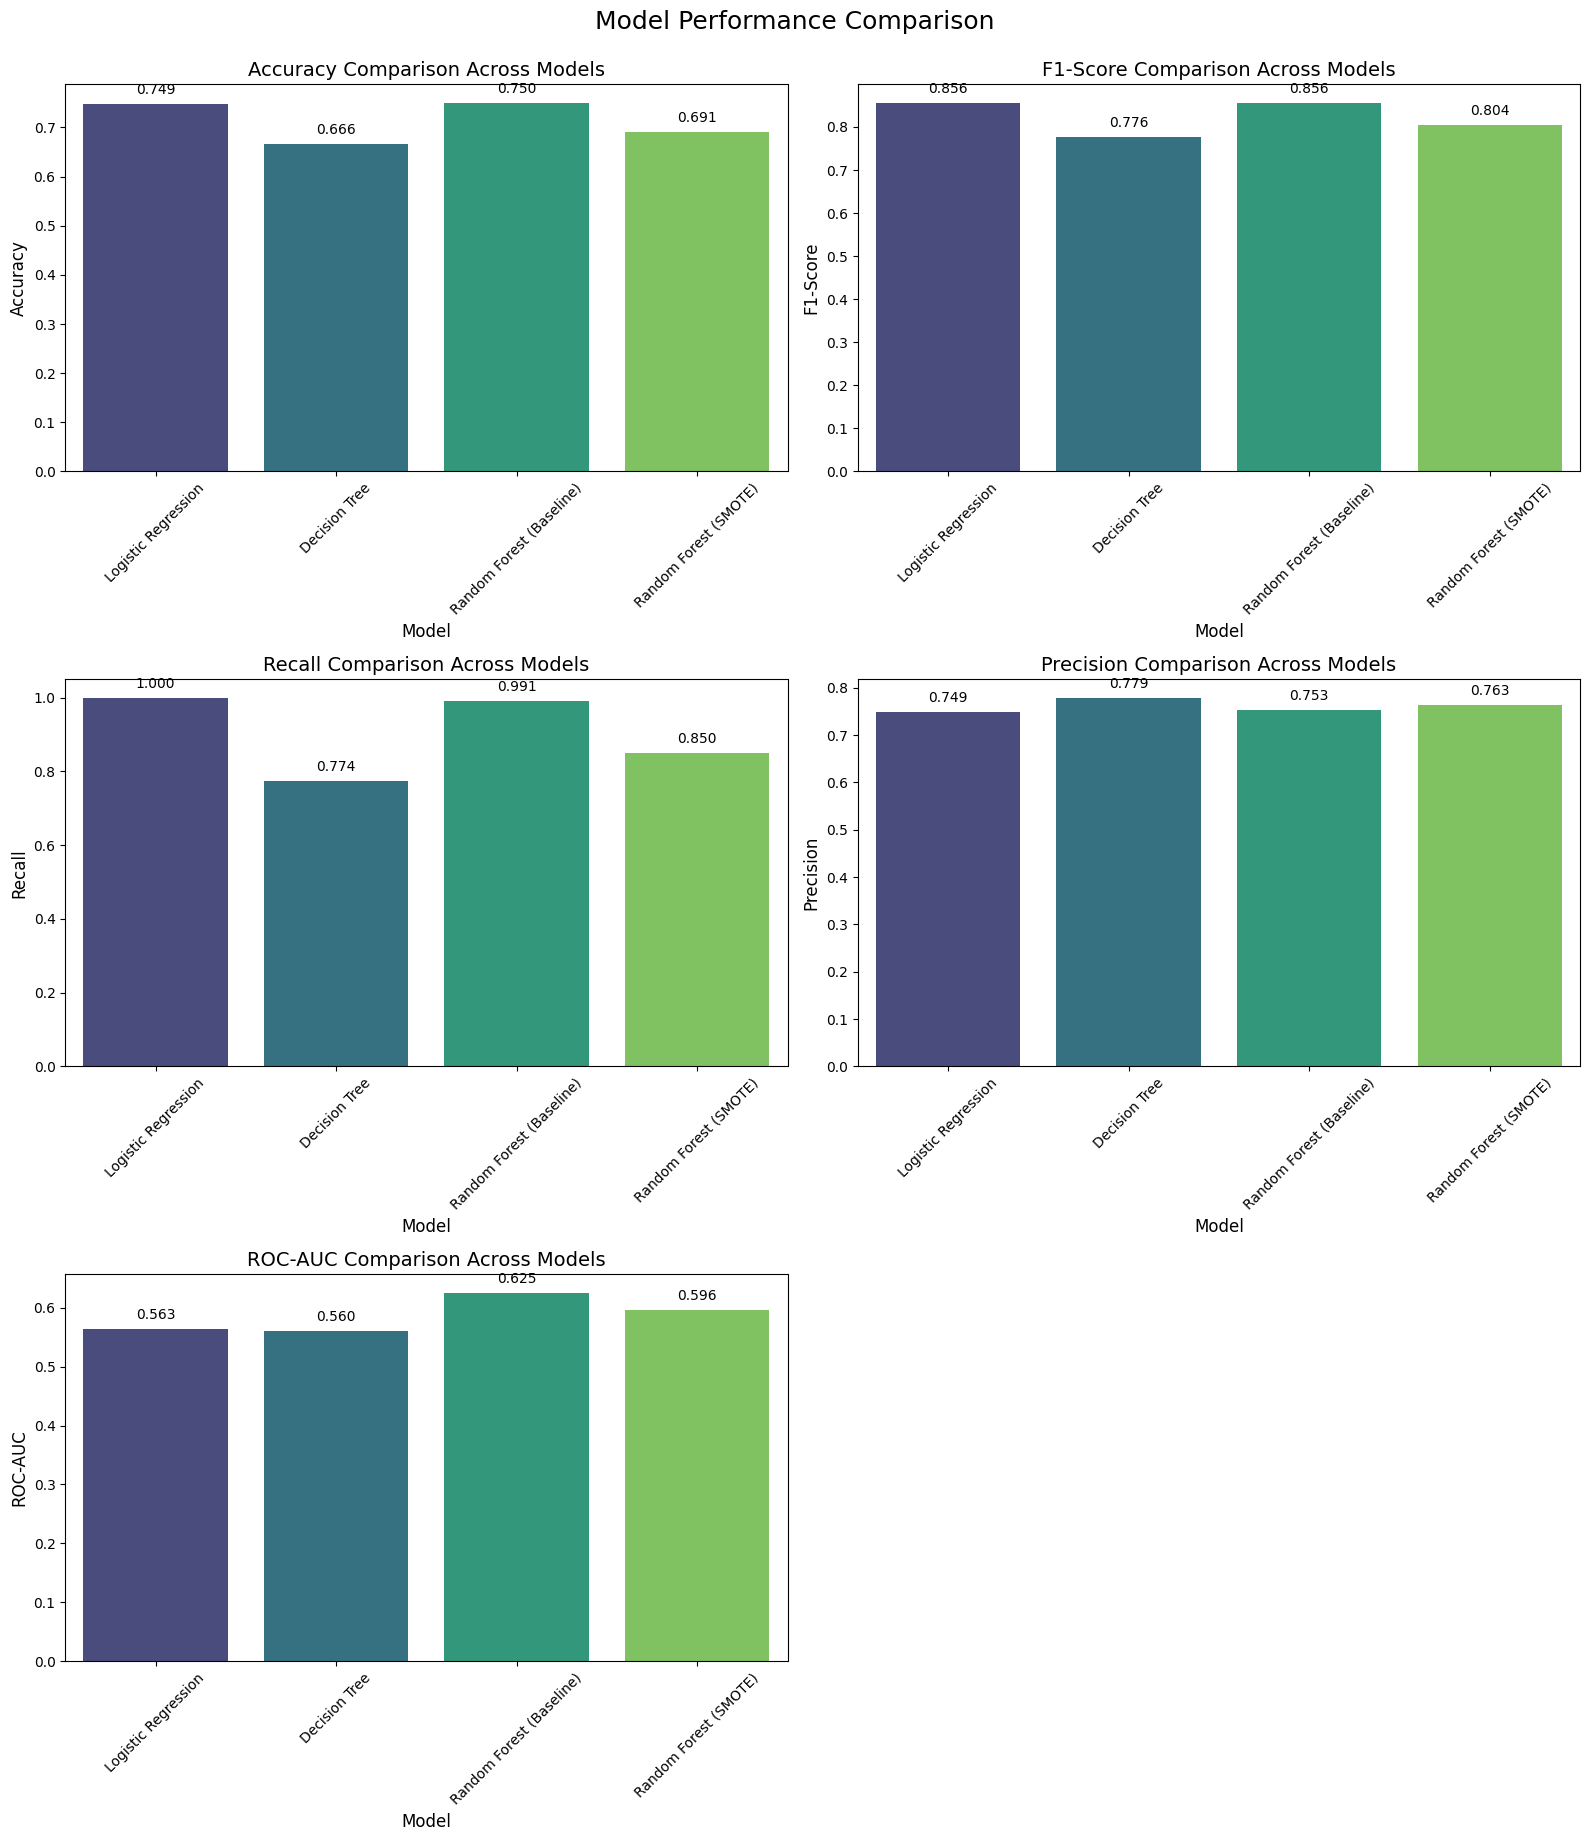

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the metrics for each model
metrics = {
    'Logistic Regression': {
        'Accuracy': 0.7486,
        'F1-Score': 0.8562,
        'Recall': 1.0000,
        'Precision': 0.7486,
        'ROC-AUC': 0.5632
    },
    'Decision Tree': {
        'Accuracy': 0.6664,
        'F1-Score': 0.7764,
        'Recall': 0.7739,
        'Precision': 0.7790,
        'ROC-AUC': 0.5600
    },
    'Random Forest (Baseline)': {
        'Accuracy': 0.7503,
        'F1-Score': 0.8560,
        'Recall': 0.9912,
        'Precision': 0.7532,
        'ROC-AUC': 0.6251
    },
    'Random Forest (SMOTE)': {
        'Accuracy': 0.6905,
        'F1-Score': 0.8044,
        'Recall': 0.8503,
        'Precision': 0.7633,
        'ROC-AUC': 0.5962
    }
}

# Convert to DataFrame for easy plotting
metrics_df = pd.DataFrame.from_dict(metrics, orient='index')

# Plotting
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten() # Flatten the 2x3 grid to easily iterate over subplots

# Remove the last empty subplot if only 5 metrics
if len(metrics_df.columns) < len(axes):
    fig.delaxes(axes[-1]) # Delete the last subplot
    axes = axes[:-1] # Remove it from the list of axes

for i, metric in enumerate(metrics_df.columns):
    sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric} Comparison Across Models', fontsize=14)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_xlabel('Model', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

    # Add value labels on top of bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f', padding=5, fontsize=10)

plt.tight_layout()
plt.suptitle('Model Performance Comparison', y=1.02, fontsize=18) # Add a main title
plt.show()

## Feature Importance Analysis from Random Forest (Baseline)

We will now extract feature importances from the Random Forest (Baseline) model to understand which features contribute most to the prediction of prior authorization `approval`.

Top 15 Most Important Features:


,Feature,Importance
6,Turnaround_Time,0.127644
5,Claim_Amount_Paid,0.115014
2,Procedure_Code,0.111381
4,Procedure_Cost,0.101574
0,Age,0.095445
9,Day,0.086017
8,Month,0.067070
10,DayOfWeek,0.053645
3,Comorbidity_Count,0.042691
1,Diagnosis_Code,0.041703


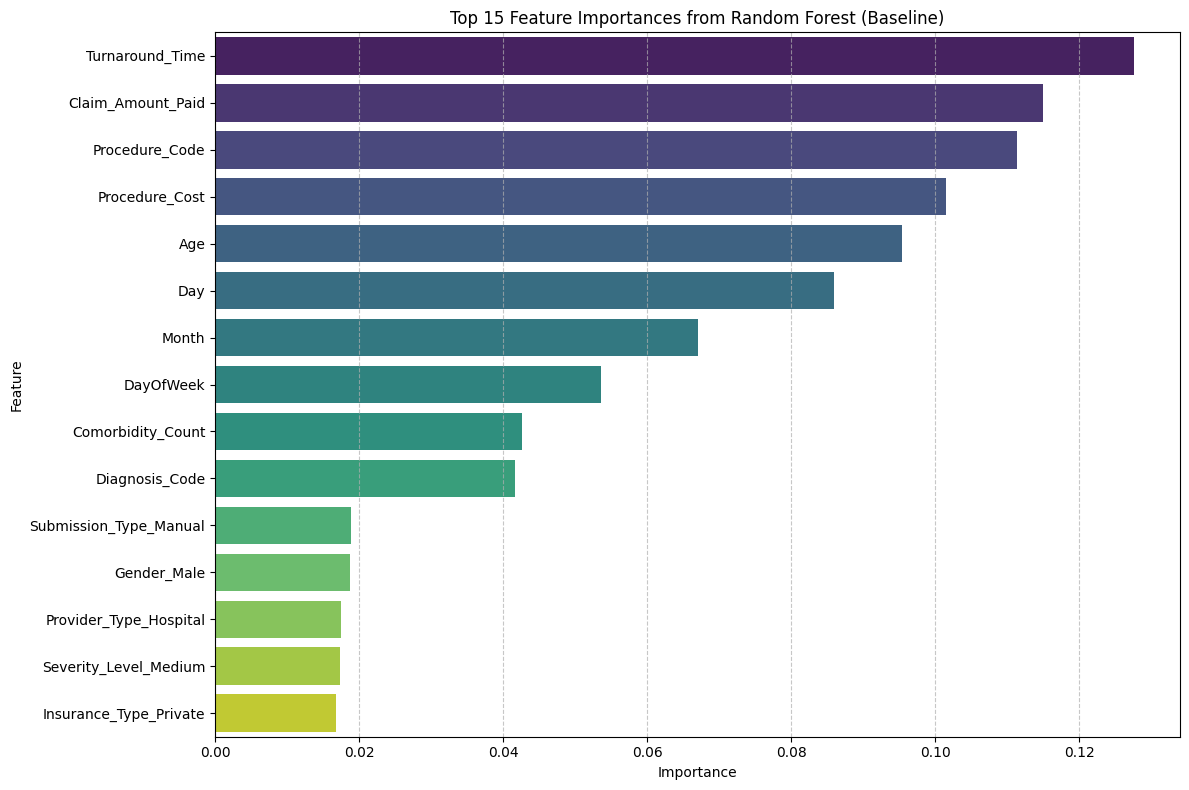

In [51]:
# Get feature importances from the Random Forest (Baseline) model
feature_importances = rf_model_base.feature_importances_

# Create a pandas Series for better visualization
features = X_train_base.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top 15 most important features
print("Top 15 Most Important Features:")
display(importance_df.head(15))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances from Random Forest (Baseline)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Multivariate Analysis based on Top Features

Based on the feature importances, we will now perform some multivariate analysis to explore relationships between the most important features and the target variable `approval`, as well as interactions among them.

Selected top features for multivariate analysis: ['Turnaround_Time', 'Claim_Amount_Paid', 'Procedure_Code', 'Procedure_Cost', 'Age', 'approval']


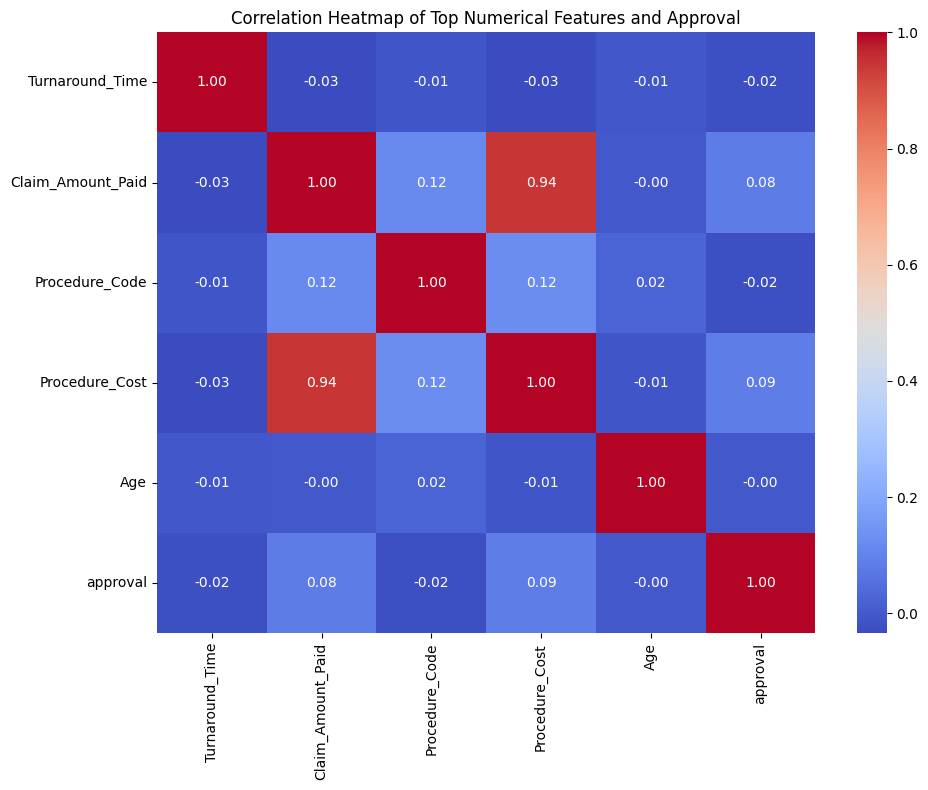


Generating pair plots for top features...


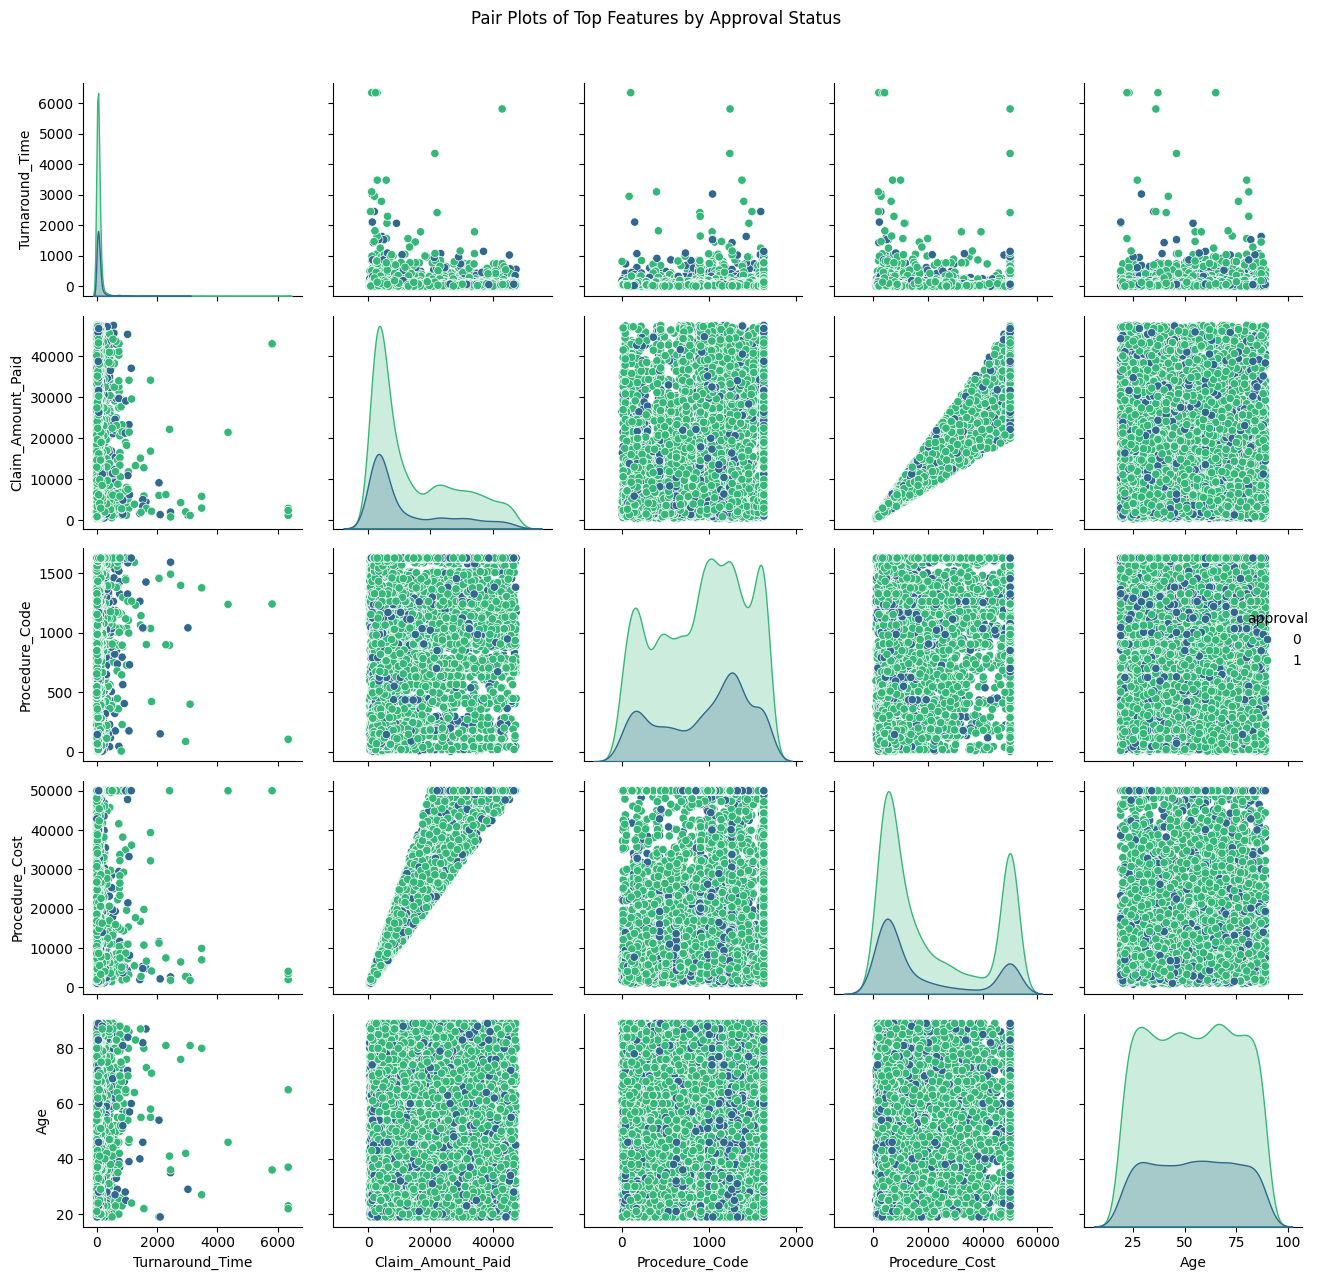

In [52]:
# Select top N features for further analysis
top_n_features = importance_df['Feature'].head(5).tolist() # Let's take the top 5
top_n_features.append('approval') # Add the target variable

# Create a subset DataFrame with these top features and the target
df_subset = df[top_n_features].copy()

print(f"Selected top features for multivariate analysis: {top_n_features}")

# --- Multivariate Analysis - Correlation Heatmap (for numerical features) ---
numerical_top_features = df_subset.select_dtypes(include=np.number).columns.tolist()

if len(numerical_top_features) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_subset[numerical_top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap of Top Numerical Features and Approval')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical top features for a correlation heatmap.")

# --- Multivariate Analysis - Pair Plots (for top features) ---
# Pair plots can reveal relationships between pairs of variables and their distribution
print("\nGenerating pair plots for top features...")
sns.pairplot(df_subset, hue='approval', palette='viridis', diag_kind='kde')
plt.suptitle('Pair Plots of Top Features by Approval Status', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

## Statistical Tests on Top Features

We will now perform statistical tests to formally assess the relationship between the top features and the `approval` status. We'll use t-tests for numerical features to compare means between approved and denied groups, and a Chi-square test for categorical features to check for independence.

In [54]:
from scipy.stats import ttest_ind, chi2_contingency

print("### T-tests for Numerical Top Features ###")
numerical_top_features_for_ttest = ['Turnaround_Time', 'Claim_Amount_Paid', 'Procedure_Cost', 'Age']

for feature in numerical_top_features_for_ttest:
    approved_group = df[df['approval'] == 1][feature]
    denied_group = df[df['approval'] == 0][feature]

    # Perform independent t-test
    stat, p_val = ttest_ind(approved_group.dropna(), denied_group.dropna(), equal_var=False) # Welch's t-test

    print(f"\n--- Feature: {feature} ---")
    print(f"Mean for Approved: {approved_group.mean():.2f}")
    print(f"Mean for Denied: {denied_group.mean():.2f}")
    print(f"T-statistic: {stat:.4f}")
    print(f"P-value: {p_val:.4f}")

    if p_val < 0.05:
        print("Conclusion: Statistically significant difference between approved and denied groups (p < 0.05).")
    else:
        print("Conclusion: No statistically significant difference between approved and denied groups (p >= 0.05).")

print("\n### Chi-square Test for Categorical Top Feature: Procedure_Code ###")
# For Procedure_Code (label encoded), we'll treat it as categorical for Chi-square test
contingency_table = pd.crosstab(df['Procedure_Code'], df['approval'])
chi2, p_val, _, _ = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: Statistically significant association between Procedure_Code and approval status (p < 0.05).")
else:
    print("Conclusion: No statistically significant association between Procedure_Code and approval status (p >= 0.05).")

### T-tests for Numerical Top Features ###

--- Feature: Turnaround_Time ---
Mean for Approved: 72.74
Mean for Denied: 85.06
T-statistic: -2.7910
P-value: 0.0053
Conclusion: Statistically significant difference between approved and denied groups (p < 0.05).

--- Feature: Claim_Amount_Paid ---
Mean for Approved: 14647.31
Mean for Denied: 12135.08
T-statistic: 7.9125
P-value: 0.0000
Conclusion: Statistically significant difference between approved and denied groups (p < 0.05).

--- Feature: Procedure_Cost ---
Mean for Approved: 21785.71
Mean for Denied: 18026.67
T-statistic: 8.3720
P-value: 0.0000
Conclusion: Statistically significant difference between approved and denied groups (p < 0.05).

--- Feature: Age ---
Mean for Approved: 54.05
Mean for Denied: 54.19
T-statistic: -0.2735
P-value: 0.7845
Conclusion: No statistically significant difference between approved and denied groups (p >= 0.05).

### Chi-square Test for Categorical Top Feature: Procedure_Code ###
Chi-square statistic: 288

## SHAP (SHapley Additive exPlanations) Analysis

SHAP is a game theory-based approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions (Lundberg & Lee, 2017).

Here, we will use SHAP to explain the predictions of our `best_rf_model` (the tuned Random Forest).

Initializing SHAP Explainer...
Calculating SHAP values (this may take a moment)...
Shape of shap_values_for_class_1: (2275, 21)
Shape of X_val_base_np: (2275, 21)
Number of feature names: 21

Generating SHAP Summary (Beeswarm) Plot...


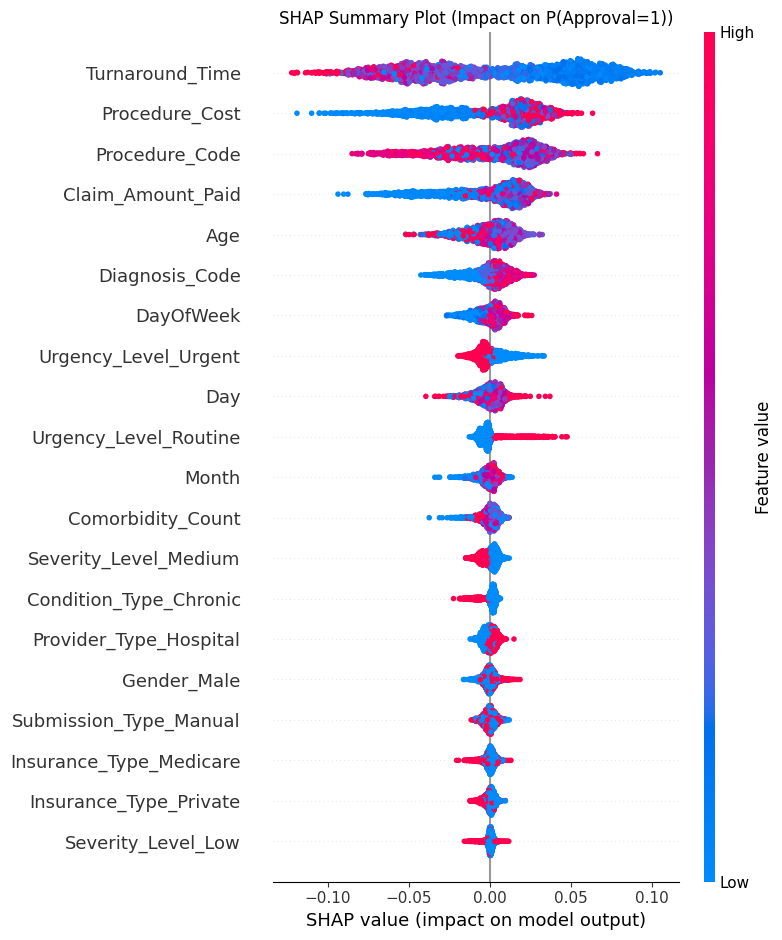


Generating SHAP Summary (Bar) Plot...


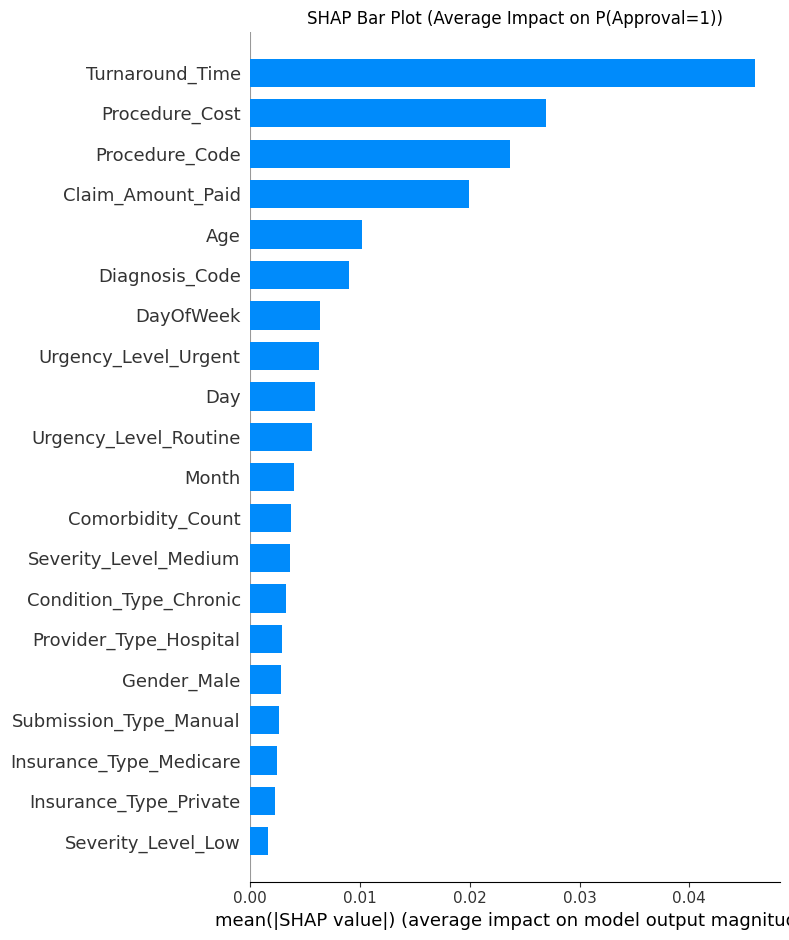


Generating SHAP Dependence Plots for: ['Turnaround_Time', 'Claim_Amount_Paid', 'Procedure_Code']


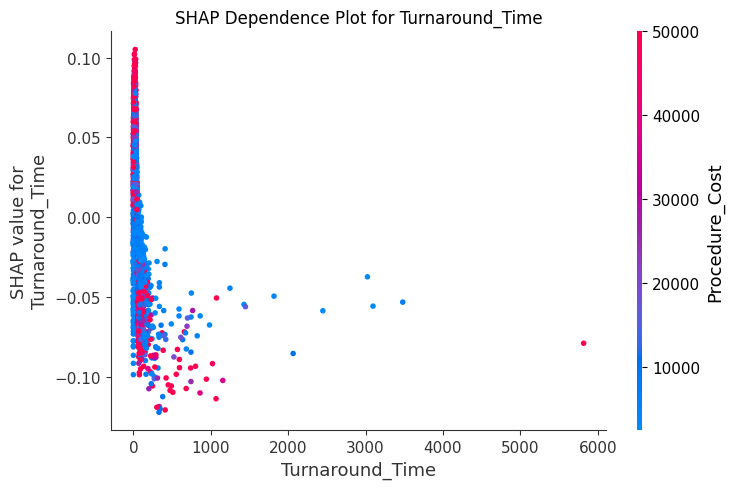

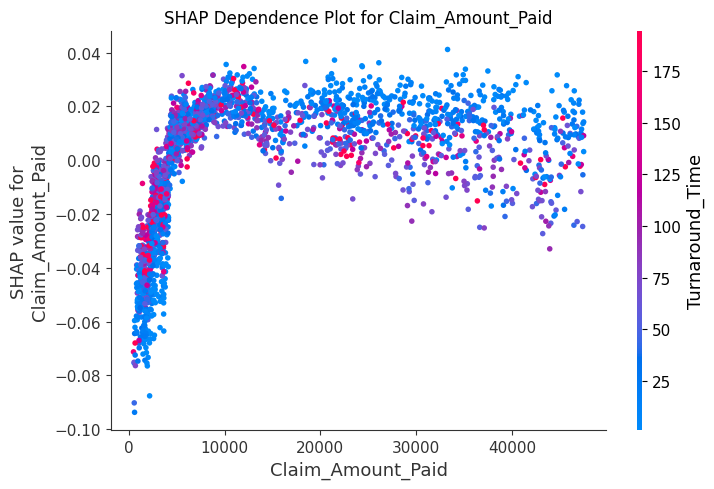

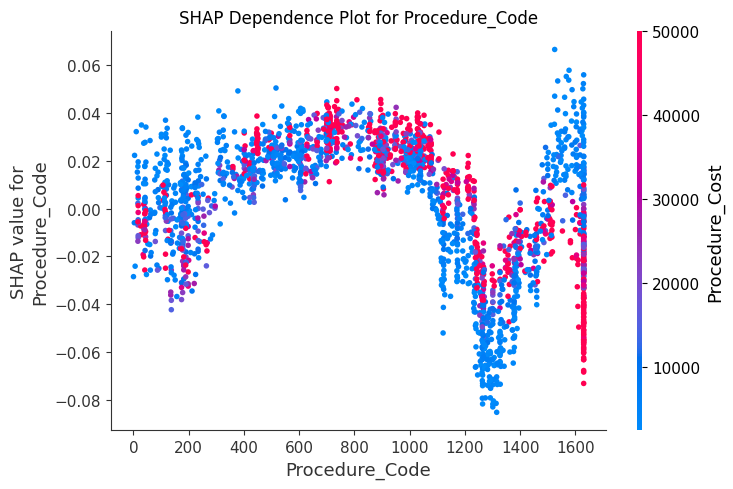

In [59]:
import shap
import matplotlib.pyplot as plt

# Assuming best_rf_model is the tuned Random Forest model from GridSearchCV
# If best_rf_model is not available, replace it with rf_model_base

print("Initializing SHAP Explainer...")
explainer = shap.TreeExplainer(best_rf_model)

# Calculate SHAP values for the validation set
print("Calculating SHAP values (this may take a moment)...")
shap_values = explainer.shap_values(X_val_base)

# Convert X_val_base to a NumPy array for SHAP plotting functions for robustness
X_val_base_np = X_val_base.values
feature_names_list = X_val_base.columns.tolist()

# Debugging shapes and feature names for consistency check
# shap_values is a 3D array of shape (n_samples, n_features, n_outputs)
# We need shap_values for the positive class (index 1) for all samples
shap_values_for_class_1 = shap_values[:, :, 1]
print(f"Shape of shap_values_for_class_1: {shap_values_for_class_1.shape}")
print(f"Shape of X_val_base_np: {X_val_base_np.shape}")
print(f"Number of feature names: {len(feature_names_list)}")

# --- SHAP Summary Plot (Beeswarm) ---
# Shows the distribution of the impact of each feature on the model output
print("\nGenerating SHAP Summary (Beeswarm) Plot...")
shap.summary_plot(shap_values_for_class_1, X_val_base_np, feature_names=feature_names_list, plot_type="dot", show=False)
plt.title('SHAP Summary Plot (Impact on P(Approval=1))')
plt.tight_layout()
plt.show()

# --- SHAP Summary Plot (Bar) ---
# Shows the average impact of each feature on the model output
print("\nGenerating SHAP Summary (Bar) Plot...")
shap.summary_plot(shap_values_for_class_1, X_val_base_np, feature_names=feature_names_list, plot_type="bar", show=False)
plt.title('SHAP Bar Plot (Average Impact on P(Approval=1))')
plt.tight_layout()
plt.show()

# --- SHAP Dependence Plots for top features ---
# Select a few top features based on the previous importance analysis
# Assuming importance_df from feature importance section is available
if 'importance_df' in locals() and not importance_df.empty:
    top_shap_features = importance_df['Feature'].head(3).tolist()
    print(f"\nGenerating SHAP Dependence Plots for: {top_shap_features}")
    for feature in top_shap_features:
        if feature in feature_names_list:
            # Keep X_val_base (DataFrame) for better labels in dependence_plot
            shap.dependence_plot(feature, shap_values_for_class_1, X_val_base, show=False)
            plt.title(f'SHAP Dependence Plot for {feature}')
            plt.tight_layout()
            plt.show()
        else:
            print(f"Warning: Feature '{feature}' not found in X_val_base. Skipping dependence plot.")
else:
    print("\n'importance_df' not found or empty. Skipping SHAP Dependence Plots.")

## Partial Dependence Plots (PDP)

Partial Dependence Plots show the marginal effect of one or two features on the predicted outcome of a fitted model. They highlight how the target variable changes as specific features change, while other features are held constant (averaged out).


Generating Partial Dependence Plots for: ['Turnaround_Time', 'Claim_Amount_Paid', 'Procedure_Code']


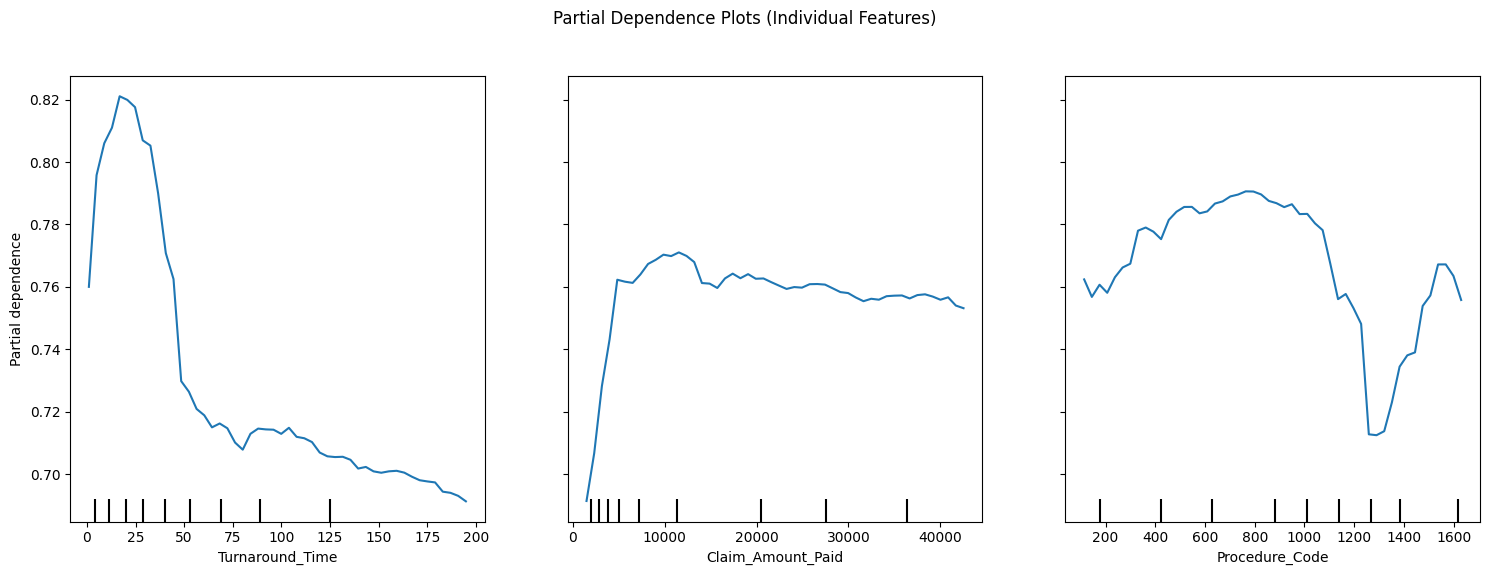


Generating Partial Dependence Plot for interaction of top 2 features...


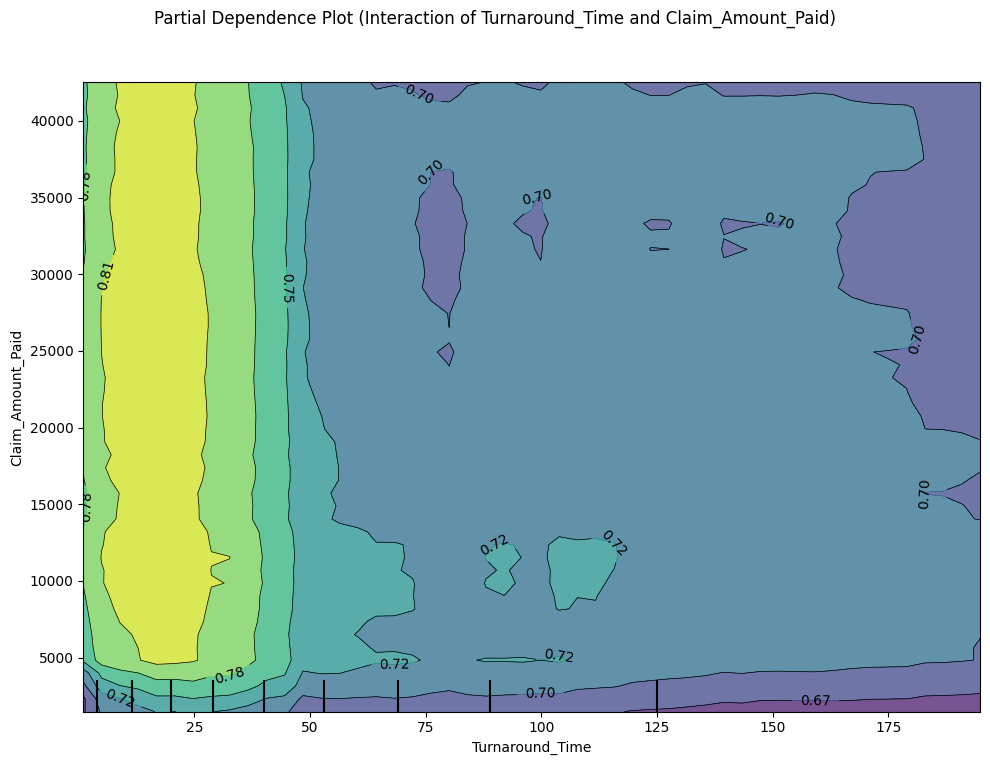

In [58]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Select the top features to visualize in PDP, typically 1 or 2 features at a time
# Re-using top features identified by SHAP or overall feature importance
if 'importance_df' in locals() and not importance_df.empty:
    features_for_pdp = importance_df['Feature'].head(3).tolist() # Get the top 3 features
    print(f"\nGenerating Partial Dependence Plots for: {features_for_pdp}")

    # Plot PDP for individual features using PartialDependenceDisplay
    fig, ax = plt.subplots(figsize=(15, 6))
    PartialDependenceDisplay.from_estimator(
        best_rf_model, X_val_base, features_for_pdp,
        feature_names=X_val_base.columns, grid_resolution=50, ax=ax
    )
    fig.suptitle('Partial Dependence Plots (Individual Features)')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

    # Optionally, plot PDP for feature interactions (e.g., top 2 features)
    if len(features_for_pdp) >= 2:
        print("\nGenerating Partial Dependence Plot for interaction of top 2 features...")
        fig, ax = plt.subplots(figsize=(10, 8))
        PartialDependenceDisplay.from_estimator(
            best_rf_model, X_val_base, [(features_for_pdp[0], features_for_pdp[1])],
            feature_names=X_val_base.columns, grid_resolution=50, ax=ax
        )
        fig.suptitle(f'Partial Dependence Plot (Interaction of {features_for_pdp[0]} and {features_for_pdp[1]})')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

else:
    print("\n'importance_df' not found or empty. Skipping Partial Dependence Plots.")

## Re-establishing Core Preprocessing Steps

Given the previous `NameError` due to undefined variables (`train_mask`, `X_train_base`, `y_train`), it appears that crucial initial data preparation steps were deleted or not executed. We will re-add these steps to ensure the DataFrame `df` is correctly structured with the target variable `approval`, datetime `Date` column, and encoded categorical/label features before proceeding with the train/validation/test split.

In [37]:
# 1. Handle Duplicates and create 'pa' (mimicking previous steps)
pa = preauthData.drop_duplicates()
print(f"Number of records after dropping duplicates: {pa.shape[0]}")

# 2. Create 'approval' column from 'PA_Status'
pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})
print("Created 'approval' column.")

# 3. Ensure 'Clinical_Notes' is string type
pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)
print("Ensured 'Clinical_Notes' is string type.")

# 4. Make a copy to work with 'df' and process 'Date' column
df = pa.copy()
df['Date'] = pd.to_datetime(df['Encounter_Date'], format='%d-%m-%Y')
print("Created 'Date' column from 'Encounter_Date'.")

# 5. Drop original ID and status columns from df
df = df.drop(columns=['Encounter_ID', 'Encounter_Date', 'PA_Status'], errors='ignore')
print("Dropped original ID and status columns.")

# 6. Extract temporal features from 'Date'
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
print("Extracted temporal features (Year, Month, Day, DayOfWeek).")

# 7. Apply One-Hot Encoding for specific categorical features
categorical_cols_onehot = [
    'Gender', 'Insurance_Type', 'Provider_Type', 'Severity_Level',
    'Urgency_Level', 'Condition_Type', 'Submission_Type'
]
existing_categorical_cols = [col for col in categorical_cols_onehot if col in df.columns]
if existing_categorical_cols:
    df = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=True)
    print(f"One-hot encoded: {existing_categorical_cols}")

# 8. Apply Label Encoding for Diagnosis_Code and Procedure_Code
from sklearn.preprocessing import LabelEncoder
categorical_cols_labelencode = ['Diagnosis_Code', 'Procedure_Code']
for col in categorical_cols_labelencode:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        print(f"Label encoded '{col}'.")

# Display the first few rows of the fully preprocessed df
print("\nFirst 5 rows of the fully preprocessed DataFrame:")
display(df.head())

Number of records after dropping duplicates: 9082
Created 'approval' column.
Ensured 'Clinical_Notes' is string type.
Created 'Date' column from 'Encounter_Date'.
Dropped original ID and status columns.
Extracted temporal features (Year, Month, Day, DayOfWeek).
One-hot encoded: ['Gender', 'Insurance_Type', 'Provider_Type', 'Severity_Level', 'Urgency_Level', 'Condition_Type', 'Submission_Type']
Label encoded 'Diagnosis_Code'.
Label encoded 'Procedure_Code'.

First 5 rows of the fully preprocessed DataFrame:


,Patient_ID,Age,Diagnosis_Code,Diagnosis_Description,Procedure_Code,Procedure_Description,Comorbidity_Count,Procedure_Cost,Claim_Amount_Paid,Clinical_Notes,...,Gender_Male,Insurance_Type_Medicare,Insurance_Type_Private,Provider_Type_Hospital,Severity_Level_Low,Severity_Level_Medium,Urgency_Level_Routine,Urgency_Level_Urgent,Condition_Type_Chronic,Submission_Type_Manual
0,P1,67,0,Type 2 Diabetes,1267,Ext Amb Infusn Pump Insulin,1,3942,2060,"Chronic disease, requires continuous monitoring",...,True,False,False,True,False,True,False,True,False,True
1,P2,30,0,Type 2 Diabetes,1266,External Ambulatory Infus Pu,2,8252,4563,"Chronic disease, requires continuous monitoring",...,False,False,True,False,False,True,False,True,True,False
2,P3,63,0,Type 2 Diabetes,1175,Monitoring feature/deviceNOC,2,6044,3675,"Chronic disease, requires continuous monitoring",...,True,False,True,True,False,False,False,False,True,False
3,P4,33,0,Type 2 Diabetes,1267,Ext Amb Infusn Pump Insulin,4,9663,5804,Patient shows severe symptoms and requires imm...,...,False,False,False,True,False,False,False,True,False,False
4,P5,21,0,Type 2 Diabetes,1266,External Ambulatory Infus Pu,2,5531,4549,"Stable condition, periodic evaluation needed",...,False,False,True,False,False,False,False,True,True,True


## Re-applying Additional Data Cleaning and Feature Engineering

Now that the core `df` structure is re-established, let's re-run the additional data cleaning and feature engineering steps that were previously implemented.

In [38]:
# Handle missing 'Procedure_Description' by filling with 'Unknown'
if 'Procedure_Description' in df.columns:
    df['Procedure_Description'] = df['Procedure_Description'].fillna('Unknown')
    print("Filled missing 'Procedure_Description' with 'Unknown'.")

# Ensure 'Diagnosis_Description' is string type and handle potential NaNs
if 'Diagnosis_Description' in df.columns:
    df['Diagnosis_Description'] = df['Diagnosis_Description'].astype(str).fillna('Unknown')
    print("Ensured 'Diagnosis_Description' is string type and handled potential NaNs.")

print(df[['Procedure_Description', 'Diagnosis_Description']].isnull().sum())

Filled missing 'Procedure_Description' with 'Unknown'.
Ensured 'Diagnosis_Description' is string type and handled potential NaNs.
Procedure_Description    0
Diagnosis_Description    0
dtype: int64


In [39]:
# Create 'Cost_Ratio' feature: Claim_Amount_Paid / Procedure_Cost
# Handle cases where Procedure_Cost might be zero to avoid division by zero errors
df['Cost_Ratio'] = df.apply(lambda row: row['Claim_Amount_Paid'] / row['Procedure_Cost'] if row['Procedure_Cost'] != 0 else 0, axis=1)
print("Created 'Cost_Ratio' feature.")

# Display descriptive statistics for the new feature
print(df['Cost_Ratio'].describe())

Created 'Cost_Ratio' feature.
count    9082.000000
mean        0.674570
std         0.157638
min         0.400062
25%         0.538980
50%         0.675024
75%         0.810575
max         0.949940
Name: Cost_Ratio, dtype: float64


In [40]:
# Create 'Age_Group' feature
bins = [0, 18, 45, 65, np.inf]
labels = ['Child', 'Adult', 'Middle_Aged', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
print("Created 'Age_Group' feature.")

# One-hot encode 'Age_Group'
df = pd.get_dummies(df, columns=['Age_Group'], drop_first=True)
print("One-hot encoded 'Age_Group'.")

# Display the first few rows with the new features
display(df.head())

Created 'Age_Group' feature.
One-hot encoded 'Age_Group'.


,Patient_ID,Age,Diagnosis_Code,Diagnosis_Description,Procedure_Code,Procedure_Description,Comorbidity_Count,Procedure_Cost,Claim_Amount_Paid,Clinical_Notes,...,Severity_Level_Low,Severity_Level_Medium,Urgency_Level_Routine,Urgency_Level_Urgent,Condition_Type_Chronic,Submission_Type_Manual,Cost_Ratio,Age_Group_Adult,Age_Group_Middle_Aged,Age_Group_Senior
0,P1,67,0,Type 2 Diabetes,1267,Ext Amb Infusn Pump Insulin,1,3942,2060,"Chronic disease, requires continuous monitoring",...,False,True,False,True,False,True,0.522577,False,False,True
1,P2,30,0,Type 2 Diabetes,1266,External Ambulatory Infus Pu,2,8252,4563,"Chronic disease, requires continuous monitoring",...,False,True,False,True,True,False,0.552957,True,False,False
2,P3,63,0,Type 2 Diabetes,1175,Monitoring feature/deviceNOC,2,6044,3675,"Chronic disease, requires continuous monitoring",...,False,False,False,False,True,False,0.608041,False,True,False
3,P4,33,0,Type 2 Diabetes,1267,Ext Amb Infusn Pump Insulin,4,9663,5804,Patient shows severe symptoms and requires imm...,...,False,False,False,True,False,False,0.600642,True,False,False
4,P5,21,0,Type 2 Diabetes,1266,External Ambulatory Infus Pu,2,5531,4549,"Stable condition, periodic evaluation needed",...,False,False,False,True,True,True,0.822455,True,False,False


In [7]:
# CMS data is no longer loaded, skipping description.
# print(cmsData.describe())

In [8]:
# EHR data is no longer loaded, skipping description.
# print(ehrData.describe())